In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from tqdm.notebook import tqdm

In [3]:

# Reading data
df = pd.read_csv('Reviews.csv', engine='python', encoding='latin1', on_bad_lines='skip')
print(df.shape)
df = df.head(500)
print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'Reviews.csv'

In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [ ]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,500.000000,500.000000,500.00000,500.000000,5.000000e+02
mean,250.500000,0.952000,1.27600,4.316000,1.294820e+09
std,144.481833,2.045988,2.48922,1.202929,5.072437e+07
min,1.000000,0.000000,0.00000,1.000000,1.107821e+09
25%,125.750000,0.000000,0.00000,4.000000,1.267790e+09
50%,250.500000,0.000000,0.00000,5.000000,1.312978e+09
75%,375.250000,1.000000,2.00000,5.000000,1.334621e+09
max,500.000000,19.000000,19.00000,5.000000,1.351210e+09


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      500 non-null    int64 
 1   ProductId               500 non-null    object
 2   UserId                  500 non-null    object
 3   ProfileName             500 non-null    object
 4   HelpfulnessNumerator    500 non-null    int64 
 5   HelpfulnessDenominator  500 non-null    int64 
 6   Score                   500 non-null    int64 
 7   Time                    500 non-null    int64 
 8   Summary                 500 non-null    object
 9   Text                    500 non-null    object
dtypes: int64(5), object(5)
memory usage: 39.2+ KB


In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


**EDA**

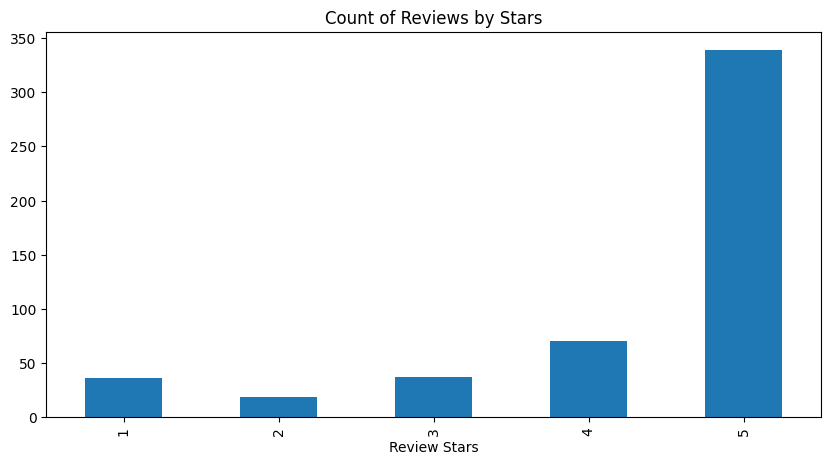

In [ ]:
ax = df['Score'].value_counts().sort_index().plot(kind='bar',
          title='Count of Reviews by Stars',figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

In [ ]:
example = df['Text'][100]
print(example)


The mouth says, "How do I love thee, let me count the ways..."<br />If you like apple products a must have item.  The only draw back, shipping cost.  These are very heavy.


In [ ]:
nltk.download('punkt_tab')
tokens = nltk.word_tokenize(example)
tokens[:10]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['The', 'mouth', 'says', ',', '``', 'How', 'do', 'I', 'love', 'thee']

In [ ]:
nltk.download('averaged_perceptron_tagger_eng')
tagged = nltk.pos_tag(tokens)
tagged[:10]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


[('The', 'DT'),
 ('mouth', 'NN'),
 ('says', 'VBZ'),
 (',', ','),
 ('``', '``'),
 ('How', 'WRB'),
 ('do', 'VB'),
 ('I', 'PRP'),
 ('love', 'VB'),
 ('thee', 'NN')]

In [ ]:
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


(S
  The/DT
  mouth/NN
  says/VBZ
  ,/,
  ``/``
  How/WRB
  do/VB
  I/PRP
  love/VB
  thee/NN
  ,/,
  let/VB
  me/PRP
  count/VB
  the/DT
  ways/NNS
  .../:
  ''/''
  </VBZ
  br/NN
  //NNP
  >/NNP
  If/IN
  you/PRP
  like/VBP
  apple/NN
  products/NNS
  a/DT
  must/MD
  have/VB
  item/NN
  ./.
  The/DT
  only/JJ
  draw/NN
  back/RB
  ,/,
  shipping/VBG
  cost/NN
  ./.
  These/DT
  are/VBP
  very/RB
  heavy/JJ
  ./.)


Vader **Model**

In [ ]:
print("\n--- Running VADER (Vectorized) ---")
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()


--- Running VADER (Vectorized) ---


In [ ]:
sia.polarity_scores('I am excited !')

{'neg': 0.0, 'neu': 0.271, 'pos': 0.729, 'compound': 0.4003}

In [ ]:
sia.polarity_scores('I hate it')

{'neg': 0.787, 'neu': 0.213, 'pos': 0.0, 'compound': -0.5719}

In [ ]:
sia.polarity_scores(example)

{'neg': 0.0, 'neu': 0.807, 'pos': 0.193, 'compound': 0.7717}

In [ ]:
# Running the polarity score on the entire dataset
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, how='left')

In [ ]:

vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


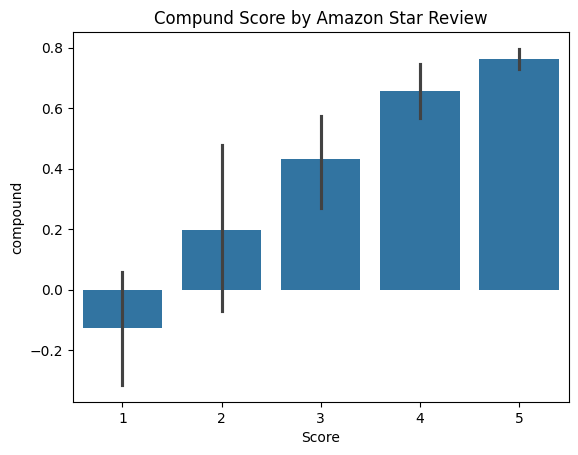

In [ ]:
ax = sns.barplot(data=vaders, x='Score', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

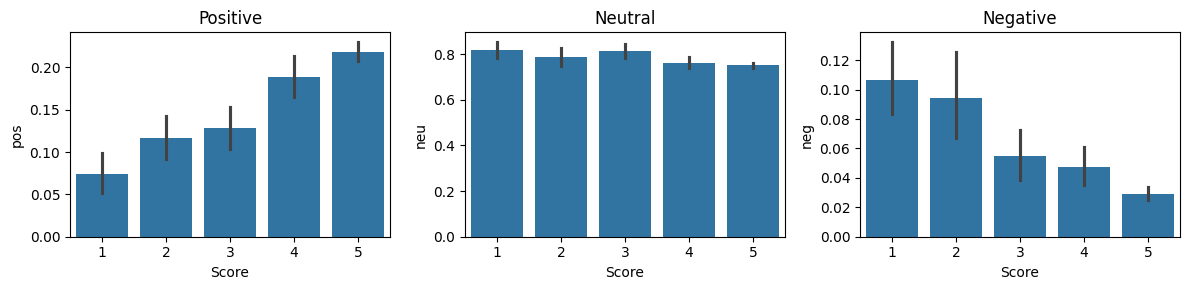

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

 **Roberta Pretrained Model**

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [ ]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [ ]:
# VADER results on example
print(example)
sia.polarity_scores(example)

The mouth says, "How do I love thee, let me count the ways..."<br />If you like apple products a must have item.  The only draw back, shipping cost.  These are very heavy.


{'neg': 0.0, 'neu': 0.807, 'pos': 0.193, 'compound': 0.7717}

In [ ]:
# Running Roberta Model
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': np.float32(0.30692145), 'roberta_neu': np.float32(0.4565689), 'roberta_pos': np.float32(0.23650964)}


In [ ]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [ ]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/500 [00:00<?, ?it/s]

Broke for id 83
Broke for id 187


In [ ]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

In [ ]:
results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

**Combine and compare**

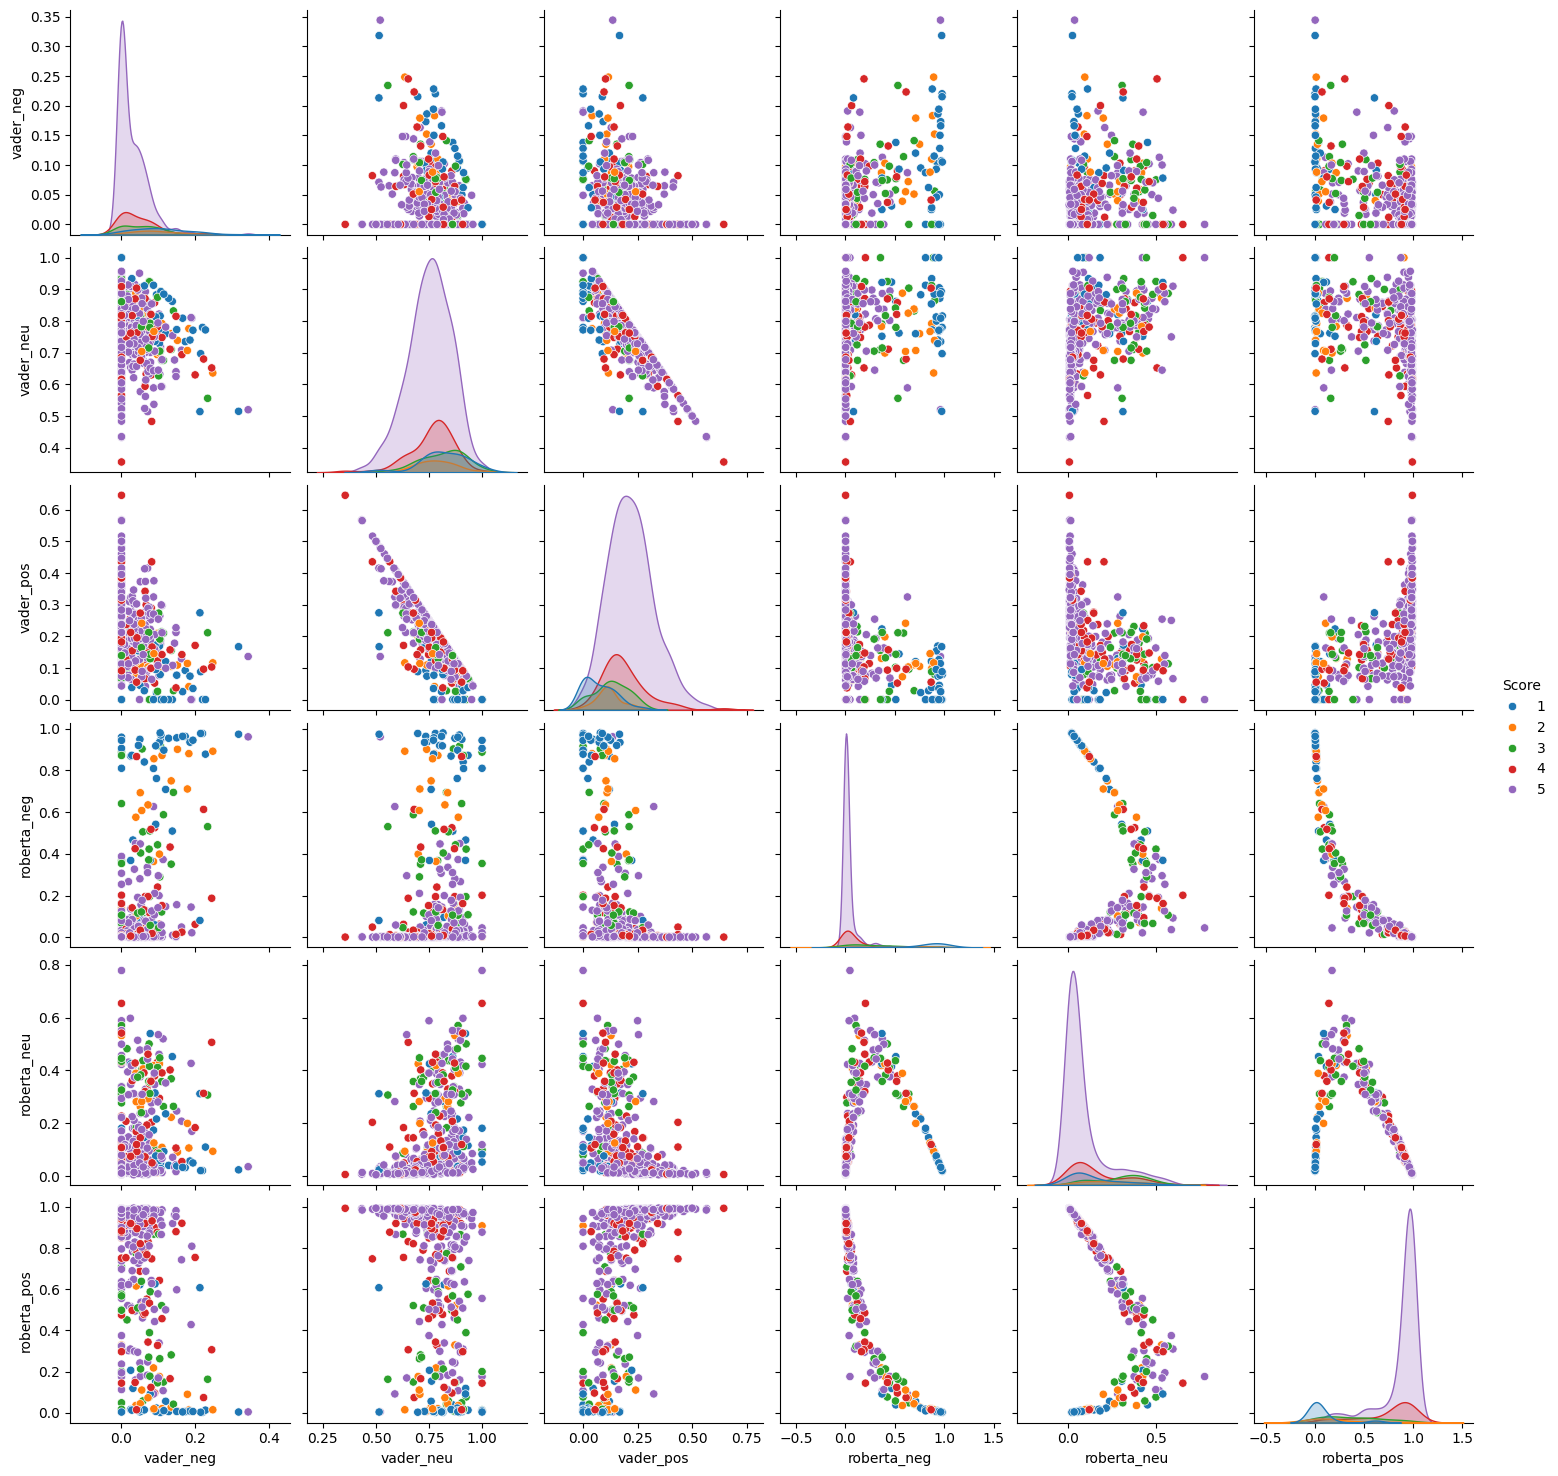

In [ ]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Score',
            palette='tab10')
plt.show()

In [ ]:
results_df.query('Score == 1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

'I felt energized within five minutes, but it lasted for about 45 minutes. I paid $3.99 for this drink. I could have just drunk a cup of coffee and saved my money.'

In [ ]:
results_df.query('Score == 1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...'

In [ ]:
# nevative sentiment 5-Star view
results_df.query('Score == 5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

In [ ]:
results_df.query('Score == 5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

In [ ]:
from transformers import pipeline

sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [ ]:
sent_pipeline('I love sentiment analysis!')

[{'label': 'POSITIVE', 'score': 0.9997853636741638}]

In [ ]:
sent_pipeline('booo')

[{'label': 'NEGATIVE', 'score': 0.9936267137527466}]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [ ]:

#  finalizing X and y
# 4-5 Stars = 1 (Positive), 1-2 Stars = 0 (Negative)
binary_df = results_df[results_df['Score'] != 3].copy()
binary_df['target'] = binary_df['Score'].apply(lambda x: 1 if x > 3 else 0)


In [ ]:

# Features (X) are the scores frm vader, roberta
X = binary_df[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
               'roberta_neg', 'roberta_neu', 'roberta_pos']]
y = binary_df['target']


In [ ]:

# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

#  SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:

#  TRAINING THE ALGORITHM
print("Training Model")
# Using Logistic Regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)


Training Model


LogisticRegression()

In [ ]:

# PREDICTIONS
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probability for ROC


In [ ]:

# PRINT PREDICTIONS
print("\n--- Prediction Snippet (First 5) ---")
print(f"Actual:    {y_test[:5].values}")
print(f"Predicted: {y_pred_test[:5]}")



--- Prediction Snippet (First 5) ---
Actual:    [1 1 1 1 1]
Predicted: [1 1 1 1 1]


In [ ]:

#  STATISTICAL OUTCOMES
print("Evaluation Metrics ")
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Evaluation Metrics 
Training Accuracy: 0.9565
Testing Accuracy:  0.9892

Confusion Matrix:
[[ 8  1]
 [ 0 84]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.99      1.00      0.99        84

    accuracy                           0.99        93
   macro avg       0.99      0.94      0.97        93
weighted avg       0.99      0.99      0.99        93



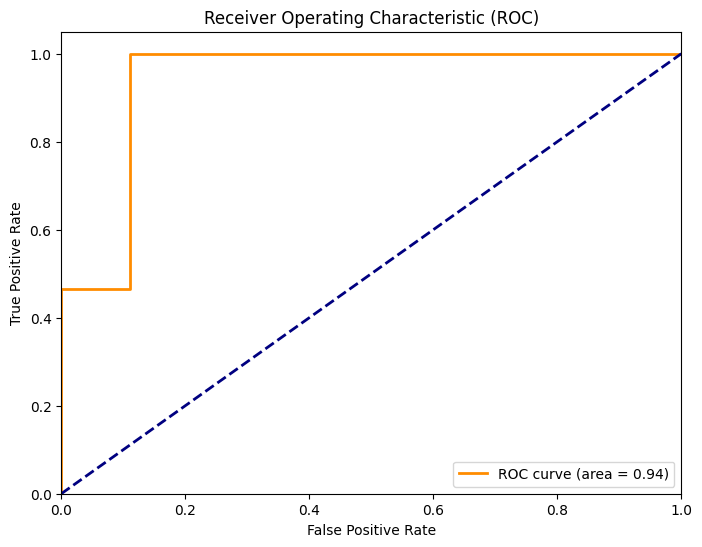

In [ ]:
#  ROC CURVE
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:

# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)




--- Training Random Forest ---


RandomForestClassifier(random_state=42)

In [ ]:
# Predictions
rf_pred = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")



Training Accuracy: 0.9565
Random Forest Accuracy: 0.9677


In [ ]:

# LINEAR SVM

from sklearn.svm import SVC
print("\n--- Training Linear SVM ---")
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)



--- Training Linear SVM ---


SVC(kernel='linear', probability=True, random_state=42)

In [ ]:

# Predictions
svm_pred = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Linear SVM Accuracy:    {accuracy_score(y_test, svm_pred):.4f}")




Training Accuracy: 0.9565
Linear SVM Accuracy:    0.9677


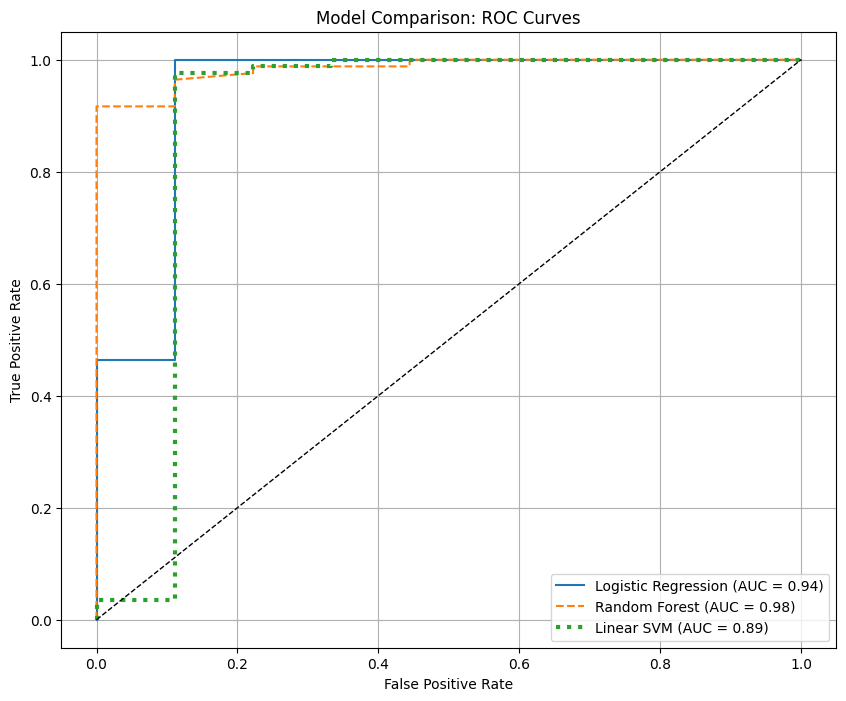

In [ ]:
plt.figure(figsize=(10, 8))

# 1. Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, linestyle='-', label=f'Logistic Regression (AUC = {auc_lr:.2f})')

# 2. Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, linestyle='--', label=f'Random Forest (AUC = {auc_rf:.2f})')

# 3. SVM ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, linestyle=':', linewidth=3, label=f'Linear SVM (AUC = {auc_svm:.2f})')

# Plot Formatting
plt.plot([0, 1], [0, 1], 'k--', lw=1) # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison: ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Actionable Insights using frequency analysis**

In [ ]:

# ACTIONABLE INSIGHTS: BIGRAM ANALYSIS

from sklearn.feature_extraction.text import CountVectorizer

def get_top_bigrams(corpus, n=None):
    # ngram_range=(2, 2) looks for exactly 2-word phrases
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # Sort by frequency (highest first)
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]


**Actionable insights using logistic regression**

In [ ]:

# SUPERVISED MODEL FOR INSIGHTS

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Vectorize the Text: Convert words into features the model can understand

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_words = tfidf.fit_transform(df['Text'].fillna(''))


In [ ]:

# Target: 1 for Positive (4-5 stars), 0 for Negative (1-2 stars)
# excluding Neutral (3) for clearer insights
mask = df['Score'] != 3
X_words_filtered = X_words[mask.values]
y_filtered = df.loc[mask, 'Score'].apply(lambda x: 1 if x > 3 else 0)


In [ ]:

# 2. Training Logistic Regression model just for insights
insight_model = LogisticRegression()
insight_model.fit(X_words_filtered, y_filtered)


LogisticRegression()

In [ ]:

coefs = pd.DataFrame(insight_model.coef_[0],
                     index=tfidf.get_feature_names_out(),
                     columns=['Weight'])



In [ ]:
# 4. Showing the Top 15 Words that drive Negative Reviews
top_complaints = coefs.sort_values(by='Weight').head(15)

print("\n--- 🤖 SUPERVISED MODEL INSIGHTS: Top Words Predicting Dissatisfaction ---")
print(top_complaints)




--- 🤖 SUPERVISED MODEL INSIGHTS: Top Words Predicting Dissatisfaction ---
                 Weight
stale         -0.898366
taste         -0.789990
terrible      -0.609471
cancelled     -0.593277
cooked        -0.587230
cream         -0.581486
return        -0.553574
minutes       -0.550414
okay          -0.546295
bad           -0.542687
bitter        -0.527029
unfortunately -0.525175
know          -0.520006
like          -0.517063
diappointed   -0.513657


/tmp/ipython-input-1099970481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_complaints['Weight'], y=top_complaints.index, palette='Reds_r')


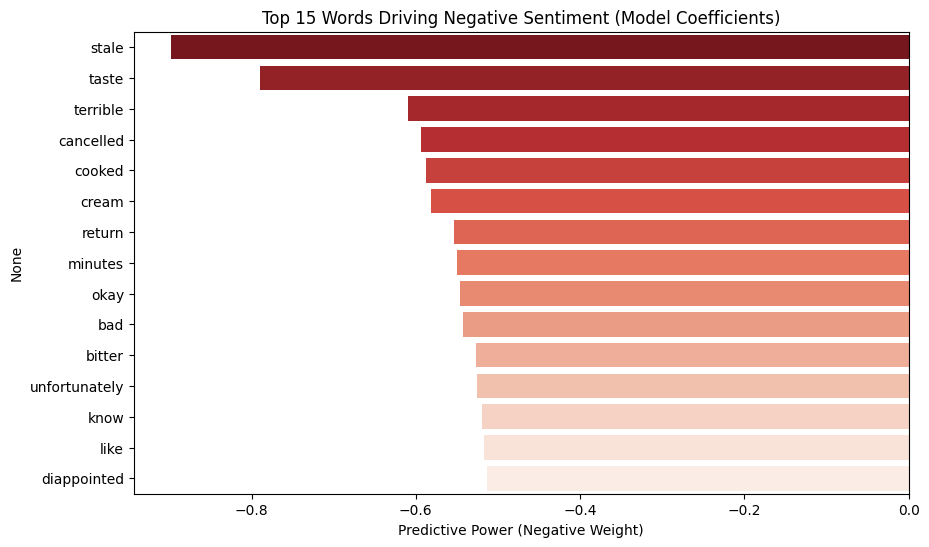

In [ ]:
# 5. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=top_complaints['Weight'], y=top_complaints.index, palette='Reds_r')
plt.title('Top 15 Words Driving Negative Sentiment (Model Coefficients)')
plt.xlabel('Predictive Power (Negative Weight)')
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [ ]:
# 1. Initialize the TreeExplainer
explainer = shap.TreeExplainer(rf_model)

In [ ]:
# 2. Calculate SHAP values
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test_scaled)

Calculating SHAP values...


In [ ]:
if isinstance(shap_values, list):
    # Old behavior: List of arrays [Class 0, Class 1]
    print("Detected List format. Extracting Class 1...")
    shap_values_pos = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    # New behavior: 3D Array (Samples, Features, Classes)
    print("Detected 3D Array format. Extracting Class 1...")
    shap_values_pos = shap_values[:, :, 1]
else:
    # Fallback: Binary case (sometimes returns just one array)
    print("Detected 2D Array format. Using as is...")
    shap_values_pos = shap_values

Detected 3D Array format. Extracting Class 1...


In [ ]:
# Double check shapes match
print(f"SHAP Shape: {shap_values_pos.shape}")
print(f"Data Shape: {X_test_scaled.shape}")

SHAP Shape: (93, 7)
Data Shape: (93, 7)


Generating Global Feature Importance Plot...


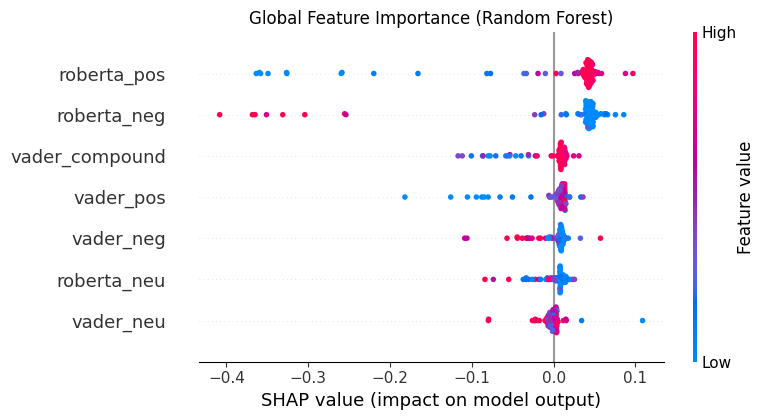

In [ ]:
# 4. VISUALIZATION: Summary Plot
print("Generating Global Feature Importance Plot...")
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (Random Forest)")
feature_names = X.columns.tolist()
shap.summary_plot(shap_values_pos, X_test_scaled, feature_names=feature_names)

Explaining the decision for the first test review:


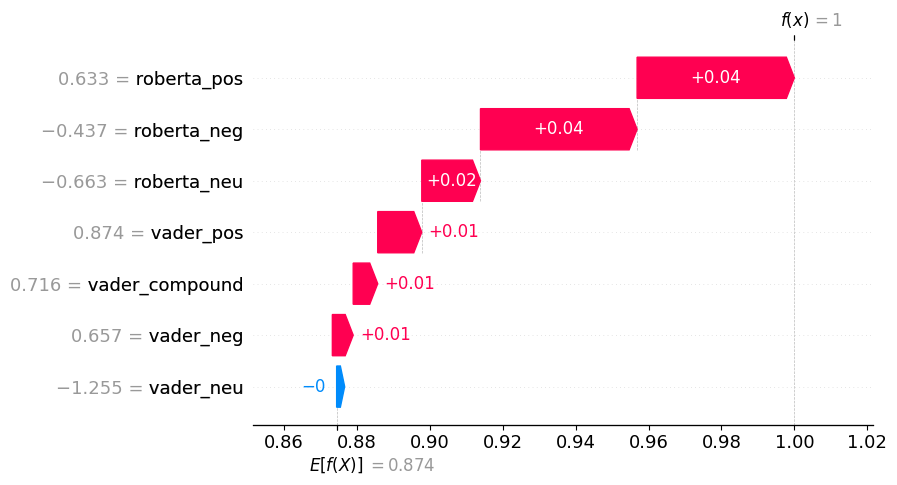

In [ ]:
# 5. VISUALIZATION: Waterfall Plot (Local Explanation)
print("Explaining the decision for the first test review:")
plt.figure()
# Create Explanation object manually to avoid version errors
exp = shap.Explanation(
    values=shap_values_pos[0],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=X_test_scaled[0],
    feature_names=feature_names
)
shap.plots.waterfall(exp)
plt.show()

In [ ]:
print("\n--- 🧠 RUNNING INNOVATION: TOPIC MODELING (LDA) ---")
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


--- 🧠 RUNNING INNOVATION: TOPIC MODELING (LDA) ---


In [ ]:
if len(negative_reviews) > 0:
    print(f"Analyzing {len(negative_reviews)} negative reviews...")

    # 2. Vectorization
    cv = CountVectorizer(max_df=0.9, min_df=2, stop_words='english')
    dtm = cv.fit_transform(negative_reviews)

    # 3. Build LDA Model
    LDA = LatentDirichletAllocation(n_components=5, random_state=42)
    LDA.fit(dtm)

    # 4. Print Top Words
    print("Top Discovered Pain Points (LDA Topics):")
    for index, topic in enumerate(LDA.components_):
        print(f'\nTHEME #{index + 1}:')
        top_words = [cv.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
        print(top_words)
else:
    print("No negative reviews found to analyze.")

Analyzing 54 negative reviews...
Top Discovered Pain Points (LDA Topics):

THEME #1:
['bag', 'little', 'order', 'hard', 'sugar', 'product', 'way', 'good', 'taste', 'like']

THEME #2:
['bad', 'like', 'cream', 'bottle', 'return', 'sure', 'price', 'good', 'just', 'taste']

THEME #3:
['products', 'bad', 'product', 'cup', 'flavor', 'like', 'taste', 'know', 've', 'tea']

THEME #4:
['formula', 'eating', 'don', 'buy', 'energy', 'cats', 'like', 'taste', 'food', 'br']

THEME #5:
['flavor', 'glass', 'chips', 'box', 'minutes', 'like', 'buy', 'br', 'just', 'sugar']
